## Import Libraries

In [1]:
import pandas as pd
import numpy as np

## Load the dataset

In [2]:
df = pd.read_csv(r"C:\Users\Bhawna\OneDrive\Desktop\E-commerce Sales Project\rfm_data.csv", 
                 names=['customer_id', 'recency', 'frequency', 'monetary'])
df.head()

,customer_id,recency,frequency,monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


## Basic informations

In [3]:
# Using describe, we  will get to know about average spend, frequency distribution, recency spread.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,4339.0,15299.936852,1721.889758,12346.0,13812.500,15299.00,16778.50,18287.00
recency,4339.0,91.518322,100.009747,0.0,17.000,50.00,141.00,373.00
frequency,4339.0,4.271952,7.705493,1.0,1.000,2.00,5.00,210.00
monetary,4339.0,2053.793018,8988.248381,0.0,307.245,674.45,1661.64,280206.02


- **Average spend** of the customers: ~2053
- **Frequency distribution**: Min = 1 invoice and Max = 210 invoices.
- **Recency spread**: 0 to 373 days

## Create segments

In [4]:
# Creating customer segment feature
df['segments'] = np.where(
    (df['recency'] <= 30) & (df['frequency'] >= 5), 'High Value',
    np.where(df['frequency'] >= 2, 'Regular',
    'Low Value'
    )
)

<Axes: ylabel='count'>

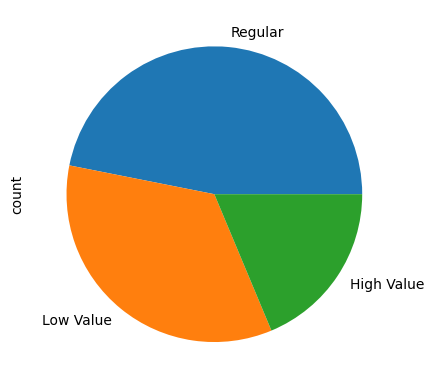

In [5]:
# Visualize the distribution of segments
df['segments'].value_counts().plot(kind='pie')

- In this dataset, **Regular customers** are approximately half of total customers.
- High value customers are less.

## Revenue by segments

In [7]:
df.groupby('segments')['monetary'].sum()

segments
High Value    5423094.510
Low Value      616311.731
Regular       2872001.663
Name: monetary, dtype: float64

## Top customers

In [8]:
df.sort_values(by='monetary', ascending=False).head()

,customer_id,recency,frequency,monetary,segments
1690,14646,1,74,280206.02,High Value
4202,18102,0,60,259657.30,High Value
3729,17450,7,46,194550.79,High Value
3009,16446,0,2,168472.50,Regular
1880,14911,0,201,143825.06,High Value


## Save final dataset

In [9]:
df.to_csv('rfm_segmented.csv',index=False)